In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os

# ==========================================
# 1. Data Loading & Processing
# ==========================================

def load_and_process_audio(filepath, target_sr=22050, n_steps=100):
    """
    Loads an audio file, extracts its RMS energy (volume envelope),
    and normalizes it to a 1D vector suitable for DTW.
    """
    print(f"Processing {filepath}...")
    
    # Load audio
    y, sr = librosa.load(filepath, sr=target_sr)
    
    # Extract RMS Energy (Amplitude Envelope)
    # This reduces the data size significantly (from samples to frames)
    # hop_length determines how many audio samples equal 1 data point
    hop_length = 512 
    rms = librosa.feature.rms(y=y, hop_length=hop_length)[0]
    
    # Normalize (Min-Max Scaling) to 0-1 range
    # This ensures we compare patterns, not volume levels
    rms_norm = (rms - np.min(rms)) / (np.max(rms) - np.min(rms))
    
    # Optional: Downsample further if the sequence is still too long for visualization
    # (For very long audio, DTW can be slow)
    if len(rms_norm) > 500:
        indices = np.linspace(0, len(rms_norm) - 1, 500).astype(int)
        rms_norm = rms_norm[indices]

    return rms_norm

# --- INPUT CONFIGURATION ---
# Replace these filenames with your actual m4a files
file_1_path = r"/Users/Shared/Files From d.localized/Christ/T5/spr/SPR lab-2448513/Lab 6/Voice 1.m4a" 
file_2_path = r"/Users/Shared/Files From d.localized/Christ/T5/spr/SPR lab-2448513/Lab 6/Voice 2.m4a"

# Check if files exist, otherwise use dummy data
if os.path.exists(file_1_path) and os.path.exists(file_2_path):
    print("Loading audio files...")
    vector_1 = load_and_process_audio(file_1_path)
    vector_2 = load_and_process_audio(file_2_path)
    data_source = "Audio Files"
else:
    print("Audio files not found. Using simulated audio data.")
    # Simulating audio envelopes (Bell curve shapes similar to spoken words)
    t = np.linspace(0, 4, 100)
    vector_1 = np.exp(-(t - 2)**2)  # Gaussian pulse
    # Vector 2 is shifted and wider (stretched)
    t2 = np.linspace(0, 5, 130) 
    vector_2 = 0.8 * np.exp(-(t2 - 3)**2 / 1.5) # Lower volume, shifted, wider
    data_source = "Simulated Data"


Loading audio files...
Processing /Users/Shared/Files From d.localized/Christ/T5/spr/SPR lab-2448513/Lab 6/Voice 1.m4a...


/var/folders/vm/ddfwc92d3bs2wrcpb_l9qw1m0000gp/T/ipykernel_4309/1121253354.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=target_sr)
/Users/Shared/Files From d.localized/Christ/T5/spr/SPR lab-2448513/SPR/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing /Users/Shared/Files From d.localized/Christ/T5/spr/SPR lab-2448513/Lab 6/Voice 2.m4a...


/var/folders/vm/ddfwc92d3bs2wrcpb_l9qw1m0000gp/T/ipykernel_4309/1121253354.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=target_sr)
/Users/Shared/Files From d.localized/Christ/T5/spr/SPR lab-2448513/SPR/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [8]:

# ==========================================
# 2. DTW Algorithm Implementation
# ==========================================
def compute_dtw(v1, v2):
    n, m = len(v1), len(v2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(v1[i-1] - v2[j-1])
            last_min = np.min([
                dtw_matrix[i-1, j],   # Insertion
                dtw_matrix[i, j-1],   # Deletion
                dtw_matrix[i-1, j-1]  # Match
            ])
            dtw_matrix[i, j] = cost + last_min
            
    return dtw_matrix

def find_optimal_path(dtw_matrix):
    i, j = dtw_matrix.shape[0] - 1, dtw_matrix.shape[1] - 1
    path = [(i-1, j-1)]
    
    while i > 1 or j > 1:
        options = [
            dtw_matrix[i-1, j-1], 
            dtw_matrix[i-1, j],   
            dtw_matrix[i, j-1]    
        ]
        best_idx = np.argmin(options)
        if best_idx == 0: i, j = i-1, j-1
        elif best_idx == 1: i = i-1
        else: j = j-1 
        path.append((i-1, j-1))
        
    path.append((0, 0))
    return path[::-1]

# Run Analysis
acc_cost_matrix = compute_dtw(vector_1, vector_2)
dtw_distance = acc_cost_matrix[-1, -1]
optimal_path = find_optimal_path(acc_cost_matrix)



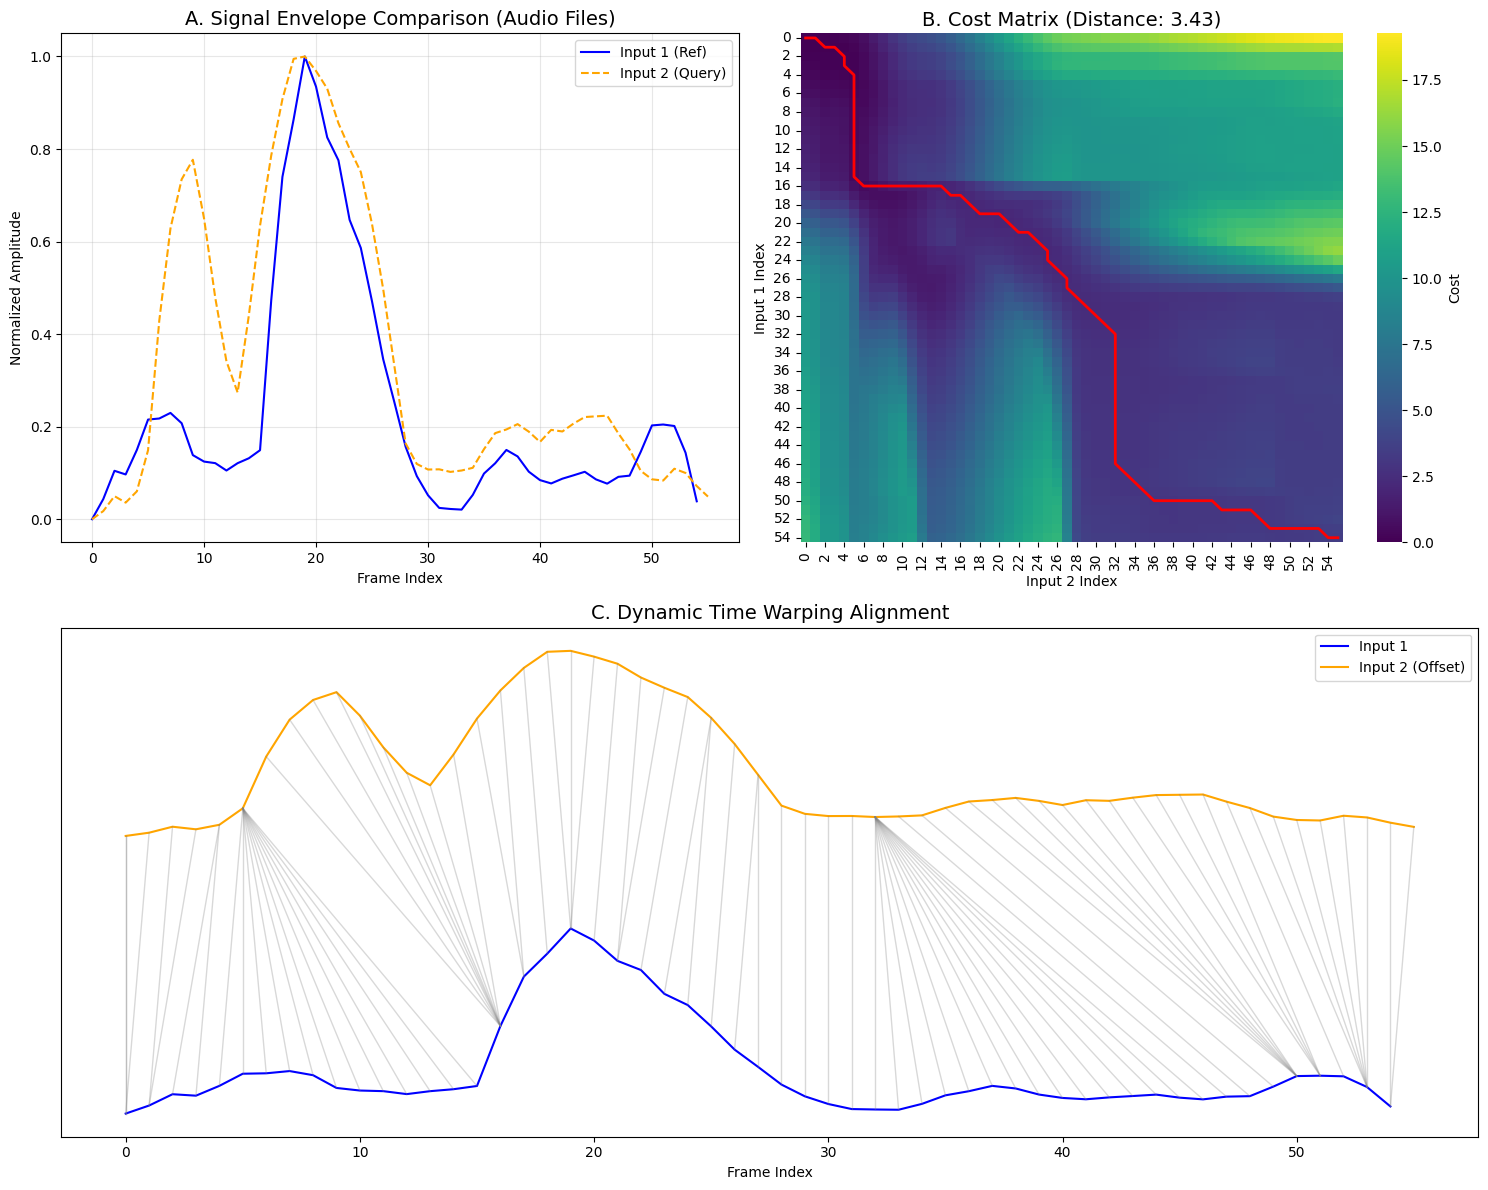

DTW Distance: 3.4335


In [9]:
# ==========================================
# 3. Visualization
# ==========================================
plt.figure(figsize=(15, 12))

# --- Subplot 1: Raw Sequence Comparison ---
plt.subplot(2, 2, 1)
plt.plot(vector_1, label='Input 1 (Ref)', color='blue', linewidth=1.5)
plt.plot(vector_2, label='Input 2 (Query)', color='orange', linestyle='--', linewidth=1.5)
plt.title(f'A. Signal Envelope Comparison ({data_source})', fontsize=14)
plt.xlabel('Frame Index')
plt.ylabel('Normalized Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Subplot 2: Accumulated Cost Matrix ---
plt.subplot(2, 2, 2)
heatmap_data = acc_cost_matrix[1:, 1:]
# Use a simpler heatmap for larger audio matrices (no annotations if large)
annot = True if len(vector_1) < 20 else False 
sns.heatmap(heatmap_data, cmap="viridis", annot=annot, fmt=".1f", cbar_kws={'label': 'Cost'})

path_x = [p[1] + 0.5 for p in optimal_path]
path_y = [p[0] + 0.5 for p in optimal_path]
plt.plot(path_x, path_y, color='red', linewidth=2, label='Optimal Path')
plt.title(f'B. Cost Matrix (Distance: {dtw_distance:.2f})', fontsize=14)
plt.xlabel('Input 2 Index')
plt.ylabel('Input 1 Index')

# --- Subplot 3: Warping Mapping ---
plt.subplot(2, 1, 2)
plt.title('C. Dynamic Time Warping Alignment', fontsize=14)

# Offset Vector 2 for visibility
offset = 1.5
plt.plot(vector_1, color='blue', label='Input 1')
plt.plot(vector_2 + offset, color='orange', label='Input 2 (Offset)')

# Draw lines (subsample lines if too many points)
step = max(1, len(optimal_path) // 50) # Limit to ~50 lines for cleanliness
for idx in range(0, len(optimal_path), step):
    i, j = optimal_path[idx]
    plt.plot([i, j], [vector_1[i], vector_2[j] + offset], color='gray', alpha=0.3, linewidth=1)

plt.yticks([])
plt.xlabel('Frame Index')
plt.legend()
plt.tight_layout()
plt.show()

print(f"DTW Distance: {dtw_distance:.4f}")